In [1]:
import anndata as ad
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

In [2]:
import matplotlib.pyplot as plt

In [3]:
from sklearn.decomposition import PCA

In [4]:
# op3 dose lookup (fixed per compound)
OP3_DEFAULT_DOSE = 1.0   # µM for most compounds
OP3_TIME = 24.0          # all op3 is 24h
op3_dose_overrides = {
    'Belinostat': 0.1,
    'DMSO':       14.1,
}
def get_op3_dose(sm_name):
    return op3_dose_overrides.get(sm_name, OP3_DEFAULT_DOSE)

# Download_data

In [5]:
op3_pseudobulk_path = '/lustre/groups/ml01/workspace/olga.novitskaia/data_updated/op3/pseudobulk_processed/group_rep/op3_standardized_processed.h5ad'
op3_var = ad.read_h5ad(op3_pseudobulk_path).var

op3_train = ad.read_h5ad('../../data/benchmark/resources/datasets/neurips-2023-data/de_train.h5ad')
compounds = pd.read_pickle('../../tahoe_sci_op3_updated.pkl')

l1000_phase1_path = '/lustre/groups/ml01/workspace/olga.novitskaia/data_updated/l1000_phase1/deg_data/group_rep/full/qc_false/filter_min_cells_0/results/'
l1000_phase1_files = sorted(os.listdir(l1000_phase1_path))

l1000_phase2_path = '/lustre/groups/ml01/workspace/olga.novitskaia/data_updated/l1000_phase2/deg_data/group_rep/full/qc_false/filter_min_cells_0/results/'
l1000_phase2_files = sorted(os.listdir(l1000_phase2_path))

In [6]:
op3_compounds = compounds[compounds['dataset'] == 'op3'].copy()

In [7]:
op3_compounds_add = pd.DataFrame({'perturbagen': ['Belinostat', 'Dabrafenib'],
                                  'smiles': ['O=C(/C=C/c1cccc(S(=O)(=O)Nc2ccccc2)c1)NO', 
                                            'CC(C)(C)c1nc(-c2cccc(NS(=O)(=O)c3c(F)cccc3F)c2F)c(-c2ccnc(N)n2)s1'],
                                  'pubchem_cid': [6918638, 44462760],
                                  'dataset': ['op3', 'op3'],
                                  'cmap_name': ['belinostat', 'dabrafenib'],
                                  'symbol': ['belinostat-10uM', 'dabrafenib-10uM'],
                                  'code': [8637, 8873],
                                  'symbol_': ['belinostat', 'dabrafenib'],
                                  'original_pert_name': ['Belinostat', 'Dabrafenib']})

In [8]:
op3_compounds = pd.concat([op3_compounds, op3_compounds_add]).reset_index(drop=True)

In [9]:
op3_compounds = op3_compounds[['perturbagen', 'original_pert_name', 'pubchem_cid']]

In [10]:
op3_var = op3_var.reset_index()
op3_train_var = op3_train.var.reset_index().rename(columns={'index': 'symbol'})

In [11]:
op3_train_var = op3_train_var.merge(op3_var, on='symbol', how='left')[['symbol', 'ensembl_id']]

In [12]:
op3_train.var = op3_train.var.merge(op3_train_var, left_index=True, right_on='symbol', how='left')

In [13]:
op3_train.var = op3_train.var.set_index('ensembl_id')

In [14]:
op3_train = op3_train[:, ~op3_train.var.index.isna()].copy()

In [15]:
op3_train.obs = op3_train.obs.merge(op3_compounds[['perturbagen', 'pubchem_cid']], left_on='sm_name', right_on='perturbagen', how='left').copy()

In [16]:
op3_train.obs['pubchem_cid'] = op3_train.obs['pubchem_cid'].astype(int).astype(str).astype('category')

In [17]:
op3_train.obs['pert_dose_uM'] = op3_train.obs['sm_name'].map(get_op3_dose)
op3_train.obs['pert_time_h'] = OP3_TIME

In [18]:
op3_train = op3_train[op3_train.obs['perturbagen'] != 'Belinostat'].copy()

/ictstr01/home/icb/olga.novitskaia/deg_venv/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [19]:
l1000_phase1 = []
for file in tqdm(l1000_phase1_files):
    l1000_phase1.append(ad.read_h5ad(l1000_phase1_path + file))

/ictstr01/home/icb/olga.novitskaia/deg_venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ictstr01/home/icb/olga.novitskaia/deg_venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ictstr01/home/icb/olga.novitskaia/deg_venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ictstr01/home/icb/olga.novitskaia/deg_venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ictstr01/home/icb/olga.novitskaia/deg_v

In [20]:
l1000_phase2 = []
for file in tqdm(l1000_phase2_files):
    l1000_phase2.append(ad.read_h5ad(l1000_phase2_path + file))

/ictstr01/home/icb/olga.novitskaia/deg_venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ictstr01/home/icb/olga.novitskaia/deg_venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ictstr01/home/icb/olga.novitskaia/deg_venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ictstr01/home/icb/olga.novitskaia/deg_venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ictstr01/home/icb/olga.novitskaia/deg_v

In [21]:
overlapping_compounds1 = {}
for j, l1000_phase1_j in enumerate(l1000_phase1):
    l1000_24h = l1000_phase1_j.obs[l1000_phase1_j.obs['pert_time_h'] == OP3_TIME]
    overlapping_compounds1[j] = len(set(op3_train.obs['pubchem_cid']).intersection(l1000_24h['pubchem_cid']))

In [22]:
overlapping_compounds2 = {}
for j, l1000_phase2_j in enumerate(l1000_phase2):
    l1000_24h = l1000_phase2_j.obs[l1000_phase2_j.obs['pert_time_h'] == OP3_TIME]
    overlapping_compounds2[j] = len(set(op3_train.obs['pubchem_cid']).intersection(l1000_24h['pubchem_cid']))

In [23]:
sorted(overlapping_compounds1.items(), key=lambda item: item[1], reverse=True)[:20]

[(6, 75),
 (8, 64),
 (48, 61),
 (4, 60),
 (67, 41),
 (62, 40),
 (69, 40),
 (60, 39),
 (64, 37),
 (7, 35),
 (10, 35),
 (18, 35),
 (21, 35),
 (29, 35),
 (68, 35),
 (65, 28),
 (16, 25),
 (20, 24),
 (63, 8),
 (5, 7)]

In [24]:
sorted(overlapping_compounds2.items(), key=lambda item: item[1], reverse=True)[:20]

[(5, 103),
 (7, 103),
 (10, 103),
 (12, 103),
 (22, 103),
 (4, 83),
 (16, 83),
 (2, 51),
 (3, 51),
 (19, 51),
 (18, 41),
 (0, 33),
 (1, 33),
 (17, 33),
 (21, 33),
 (24, 33),
 (25, 33),
 (26, 33),
 (27, 33),
 (28, 33)]

## Correlation: best L1000 match (unconstrained)

/ictstr01/home/icb/olga.novitskaia/deg_venv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/ictstr01/home/icb/olga.novitskaia/deg_venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████| 30/30 [00:11<00:00,  2.64it/s]


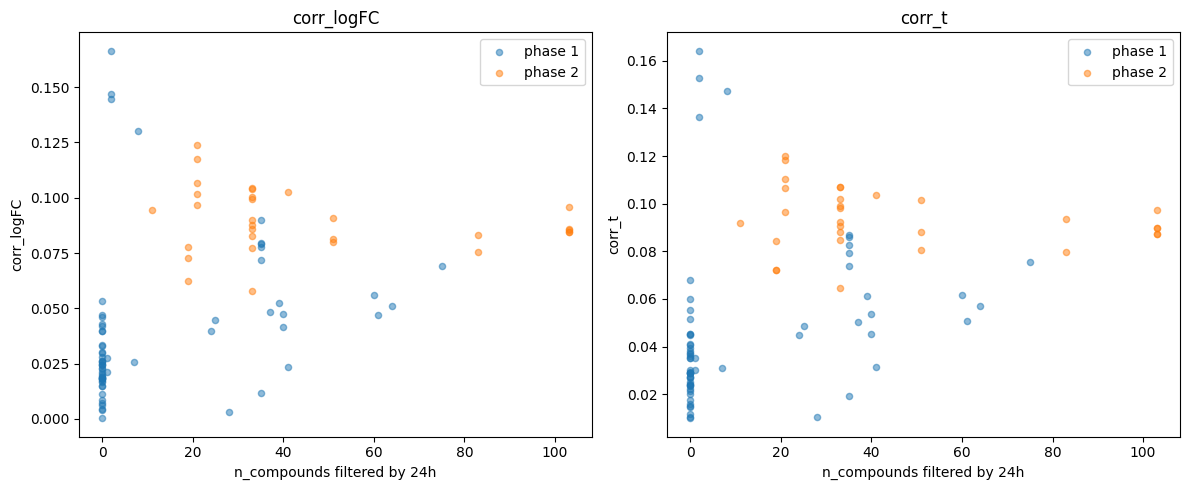

In [25]:
def cross_corr_matrix(a, b):
    """Returns (n_a, n_b) Pearson correlation matrix between rows of a and rows of b."""
    a = a - a.mean(axis=1, keepdims=True)
    b = b - b.mean(axis=1, keepdims=True)
    a = a / np.linalg.norm(a, axis=1, keepdims=True)
    b = b / np.linalg.norm(b, axis=1, keepdims=True)
    return a @ b.T

corr_logFC1 = {}

for j in tqdm(range(len(l1000_phase1))):
    genes = op3_train.var[op3_train.var.index.isin(l1000_phase1[j].var.index)].index
    compounds = set(op3_train.obs['pubchem_cid']).intersection(l1000_phase1[j].obs['pubchem_cid'])
    corr_values = []
    for compound in compounds:
        a = op3_train[op3_train.obs['pubchem_cid'] == compound, genes].layers['logFC']
        b = l1000_phase1[j][l1000_phase1[j].obs['pubchem_cid'] == compound, genes].layers['logFC']
        corr_values.extend(cross_corr_matrix(a, b).max(axis=1).tolist())
    corr_logFC1[j] = np.mean(corr_values)


corr_logFC2 = {}
for j in tqdm(range(len(l1000_phase2))):
    genes = op3_train.var[op3_train.var.index.isin(l1000_phase2[j].var.index)].index
    compounds = set(op3_train.obs['pubchem_cid']).intersection(l1000_phase2[j].obs['pubchem_cid'])
    corr_values = []
    for compound in compounds:
        a = op3_train[op3_train.obs['pubchem_cid'] == compound, genes].layers['logFC']
        b = l1000_phase2[j][l1000_phase2[j].obs['pubchem_cid'] == compound, genes].layers['logFC']
        corr_values.extend(cross_corr_matrix(a, b).max(axis=1).tolist())
    corr_logFC2[j] = np.mean(corr_values)

corr_t1 = {}
for j in tqdm(range(len(l1000_phase1))):
    genes = op3_train.var[op3_train.var.index.isin(l1000_phase1[j].var.index)].index
    compounds = set(op3_train.obs['pubchem_cid']).intersection(l1000_phase1[j].obs['pubchem_cid'])
    corr_values = []
    for compound in compounds:
        a = op3_train[op3_train.obs['pubchem_cid'] == compound, genes].layers['t']
        b = l1000_phase1[j][l1000_phase1[j].obs['pubchem_cid'] == compound, genes].layers['t']
        corr_values.extend(cross_corr_matrix(a, b).max(axis=1).tolist())
    corr_t1[j] = np.mean(corr_values)

corr_t2 = {}

for j in tqdm(range(len(l1000_phase2))):
    genes = op3_train.var[op3_train.var.index.isin(l1000_phase2[j].var.index)].index
    compounds = set(op3_train.obs['pubchem_cid']).intersection(l1000_phase2[j].obs['pubchem_cid'])
    corr_values = []
    for compound in compounds:
        a = op3_train[op3_train.obs['pubchem_cid'] == compound, genes].layers['t']
        b = l1000_phase2[j][l1000_phase2[j].obs['pubchem_cid'] == compound, genes].layers['t']
        corr_values.extend(cross_corr_matrix(a, b).max(axis=1).tolist())
    corr_t2[j] = np.mean(corr_values)

rows = []
for phase, l1000_list, overlapping_compounds, corr_logFC, corr_t in [
    (1, l1000_phase1, overlapping_compounds1, corr_logFC1, corr_t1),
    (2, l1000_phase2, overlapping_compounds2, corr_logFC2, corr_t2),
]:
    for j, l1000_j in enumerate(l1000_list):
        l1000_cell_type = l1000_j.obs['cell_type'].unique()[0]
        rows.append({
            'l1000_j':          j,
            'l1000_cell_type':  l1000_cell_type,
            'phase':            phase,
            'n_compounds':      overlapping_compounds[j],
            'corr_logFC':       corr_logFC.get(j, np.nan),
            'corr_t':           corr_t.get(j, np.nan),
        })
df_results = pd.DataFrame(rows)
pd.set_option('display.max_rows', 100) 
df_results.sort_values(['n_compounds', 'corr_t'], ascending=False)#.groupby(['op3_cell_type', 'phase']).head(10)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, corr_col in zip(axes, ['corr_logFC', 'corr_t']):
    for phase, grp in df_results.groupby('phase'):
        ax.scatter(grp['n_compounds'], grp[corr_col], 
                   label=f'phase {phase}', alpha=0.5, s=20)
    ax.set_xlabel('n_compounds filtered by 24h')
    ax.set_ylabel(corr_col)
    ax.legend()
    ax.set_title(corr_col)
plt.tight_layout()


## Corr dose-matched

In [26]:
corr_logFC1_matched = {}

for j in tqdm(range(len(l1000_phase1))):
    # filter l1000 to 24h first, then compute overlapping compounds and genes
    l1000_time_mask = (l1000_phase1[j].obs['pert_time_h'] == OP3_TIME).values
    l1000_j_24h_obs = l1000_phase1[j].obs[l1000_time_mask].copy()
    l1000_j_24h_obs['log_dose'] = np.log(l1000_j_24h_obs['pert_dose_uM'])

    compounds = set(op3_train.obs['pubchem_cid']).intersection(l1000_j_24h_obs['pubchem_cid'])
    genes = op3_train.var[op3_train.var.index.isin(l1000_phase1[j].var.index)].index

    # extract numpy arrays upfront — no AnnData indexing in the loop
    op3_gene_mask = op3_train.var.index.isin(genes)
    op3_X = op3_train.layers['logFC'][:, op3_gene_mask]

    l1000_gene_mask = l1000_phase1[j].var.index.isin(genes)
    l1000_j_24h_X = l1000_phase1[j].layers['logFC'][l1000_time_mask, :][:, l1000_gene_mask]
    corr_values = []
    for compound in compounds:
        op3_mask      = (op3_train.obs['pubchem_cid'] == compound).values
        l1000_mask    = (l1000_j_24h_obs['pubchem_cid'] == compound).values
        l1000_cid_obs = l1000_j_24h_obs[l1000_mask]
        if len(l1000_cid_obs) == 0:
            continue
        sm_name      = op3_train.obs.loc[op3_mask, 'sm_name'].iloc[0]
        op3_log_dose = np.log(get_op3_dose(sm_name))
        closest_pos  = (l1000_cid_obs['log_dose'] - op3_log_dose).abs().argmin()
        closest_int  = np.where(l1000_mask)[0][closest_pos]
        a = op3_X[op3_mask, :]
        b = l1000_j_24h_X[[closest_int], :]
        
        corr_values.extend(cross_corr_matrix(a, b).flatten().tolist())
    corr_logFC1_matched[j] = np.mean(corr_values) if corr_values else np.nan

/ictstr01/home/icb/olga.novitskaia/deg_venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/ictstr01/home/icb/olga.novitskaia/deg_venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/ictstr01/home/icb/olga.novitskaia/deg_venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
100%|██████████| 70/70 [00:01<00:00, 42.59it/s]


In [27]:
corr_logFC2_matched = {}

for j in tqdm(range(len(l1000_phase2))):
    # filter l1000 to 24h first, then compute overlapping compounds and genes
    l1000_time_mask = (l1000_phase2[j].obs['pert_time_h'] == OP3_TIME).values
    l1000_j_24h_obs = l1000_phase2[j].obs[l1000_time_mask].copy()
    l1000_j_24h_obs['log_dose'] = np.log(l1000_j_24h_obs['pert_dose_uM'])

    compounds = set(op3_train.obs['pubchem_cid']).intersection(l1000_j_24h_obs['pubchem_cid'])
    genes = op3_train.var[op3_train.var.index.isin(l1000_phase2[j].var.index)].index

    # extract numpy arrays upfront — no AnnData indexing in the loop
    op3_gene_mask = op3_train.var.index.isin(genes)
    op3_X = op3_train.layers['logFC'][:, op3_gene_mask]

    l1000_gene_mask = l1000_phase2[j].var.index.isin(genes)
    l1000_j_24h_X = l1000_phase2[j].layers['logFC'][l1000_time_mask, :][:, l1000_gene_mask]
    corr_values = []
    for compound in compounds:
        op3_mask      = (op3_train.obs['pubchem_cid'] == compound).values
        l1000_mask    = (l1000_j_24h_obs['pubchem_cid'] == compound).values
        l1000_cid_obs = l1000_j_24h_obs[l1000_mask]
        if len(l1000_cid_obs) == 0:
            continue
        sm_name      = op3_train.obs.loc[op3_mask, 'sm_name'].iloc[0]
        op3_log_dose = np.log(get_op3_dose(sm_name))
        closest_pos  = (l1000_cid_obs['log_dose'] - op3_log_dose).abs().argmin()
        closest_int  = np.where(l1000_mask)[0][closest_pos]
        a = op3_X[op3_mask, :]
        b = l1000_j_24h_X[[closest_int], :]

        corr_values.extend(cross_corr_matrix(a, b).flatten().tolist())
    corr_logFC2_matched[j] = np.mean(corr_values) if corr_values else np.nan

100%|██████████| 30/30 [00:02<00:00, 14.71it/s]


In [28]:
corr_t1_matched = {}

for j in tqdm(range(len(l1000_phase1))):
    # filter l1000 to 24h first, then compute overlapping compounds and genes
    l1000_time_mask = (l1000_phase1[j].obs['pert_time_h'] == OP3_TIME).values
    l1000_j_24h_obs = l1000_phase1[j].obs[l1000_time_mask].copy()
    l1000_j_24h_obs['log_dose'] = np.log(l1000_j_24h_obs['pert_dose_uM'])

    compounds = set(op3_train.obs['pubchem_cid']).intersection(l1000_j_24h_obs['pubchem_cid'])
    genes = op3_train.var[op3_train.var.index.isin(l1000_phase1[j].var.index)].index

    # extract numpy arrays upfront — no AnnData indexing in the loop
    op3_gene_mask = op3_train.var.index.isin(genes)
    op3_X = op3_train.layers['t'][:, op3_gene_mask]

    l1000_gene_mask = l1000_phase1[j].var.index.isin(genes)
    l1000_j_24h_X = l1000_phase1[j].layers['t'][l1000_time_mask, :][:, l1000_gene_mask]
    corr_values = []
    for compound in compounds:
        op3_mask      = (op3_train.obs['pubchem_cid'] == compound).values
        l1000_mask    = (l1000_j_24h_obs['pubchem_cid'] == compound).values
        l1000_cid_obs = l1000_j_24h_obs[l1000_mask]
        if len(l1000_cid_obs) == 0:
            continue
        sm_name      = op3_train.obs.loc[op3_mask, 'sm_name'].iloc[0]
        op3_log_dose = np.log(get_op3_dose(sm_name))
        closest_pos  = (l1000_cid_obs['log_dose'] - op3_log_dose).abs().argmin()
        closest_int  = np.where(l1000_mask)[0][closest_pos]
        a = op3_X[op3_mask, :]
        b = l1000_j_24h_X[[closest_int], :]

        corr_values.extend(cross_corr_matrix(a, b).flatten().tolist())
    corr_t1_matched[j] = np.mean(corr_values) if corr_values else np.nan

/ictstr01/home/icb/olga.novitskaia/deg_venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/ictstr01/home/icb/olga.novitskaia/deg_venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/ictstr01/home/icb/olga.novitskaia/deg_venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
100%|██████████| 70/70 [00:01<00:00, 43.79it/s]


In [29]:
corr_t2_matched = {}

for j in tqdm(range(len(l1000_phase2))):
    # filter l1000 to 24h first, then compute overlapping compounds and genes
    l1000_time_mask = (l1000_phase2[j].obs['pert_time_h'] == OP3_TIME).values
    l1000_j_24h_obs = l1000_phase2[j].obs[l1000_time_mask].copy()
    l1000_j_24h_obs['log_dose'] = np.log(l1000_j_24h_obs['pert_dose_uM'])

    compounds = set(op3_train.obs['pubchem_cid']).intersection(l1000_j_24h_obs['pubchem_cid'])
    genes = op3_train.var[op3_train.var.index.isin(l1000_phase2[j].var.index)].index

    # extract numpy arrays upfront — no AnnData indexing in the loop
    op3_gene_mask = op3_train.var.index.isin(genes)
    op3_X = op3_train.layers['t'][:, op3_gene_mask]

    l1000_gene_mask = l1000_phase2[j].var.index.isin(genes)
    l1000_j_24h_X = l1000_phase2[j].layers['t'][l1000_time_mask, :][:, l1000_gene_mask]
    corr_values = []
    for compound in compounds:
        op3_mask      = (op3_train.obs['pubchem_cid'] == compound).values
        l1000_mask    = (l1000_j_24h_obs['pubchem_cid'] == compound).values
        l1000_cid_obs = l1000_j_24h_obs[l1000_mask]
        if len(l1000_cid_obs) == 0:
            continue
        sm_name      = op3_train.obs.loc[op3_mask, 'sm_name'].iloc[0]
        op3_log_dose = np.log(get_op3_dose(sm_name))
        closest_pos  = (l1000_cid_obs['log_dose'] - op3_log_dose).abs().argmin()
        closest_int  = np.where(l1000_mask)[0][closest_pos]
        a = op3_X[op3_mask, :]
        b = l1000_j_24h_X[[closest_int], :]

        corr_values.extend(cross_corr_matrix(a, b).flatten().tolist())
    corr_t2_matched[j] = np.mean(corr_values) if corr_values else np.nan

100%|██████████| 30/30 [00:02<00:00, 14.18it/s]


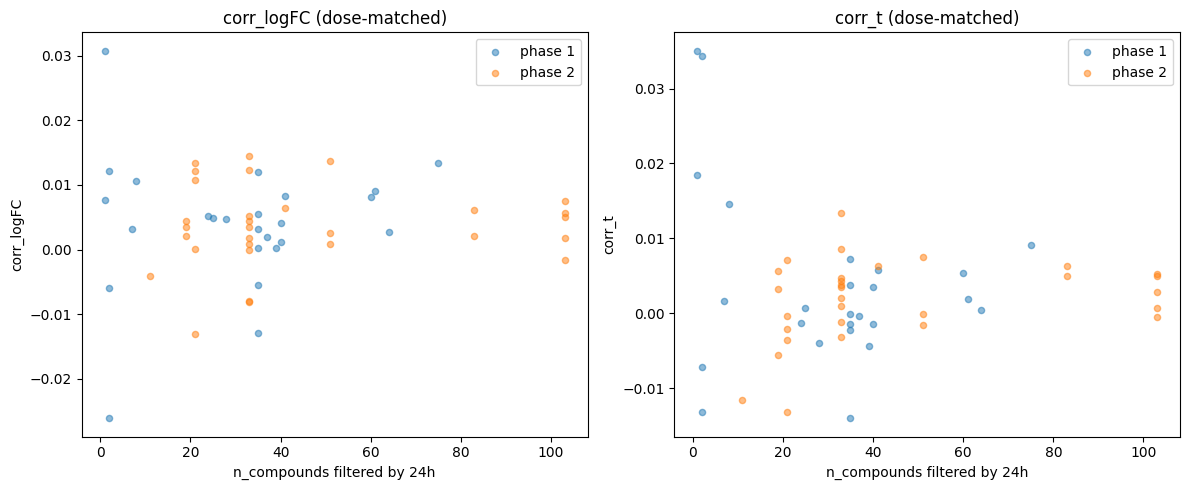

In [30]:
rows = []
for phase, l1000_list, overlapping_compounds, corr_logFC, corr_t in [
    (1, l1000_phase1, overlapping_compounds1, corr_logFC1_matched, corr_t1_matched),
    (2, l1000_phase2, overlapping_compounds2, corr_logFC2_matched, corr_t2_matched),
]:
    for j, l1000_j in enumerate(l1000_list):
        l1000_cell_type = l1000_j.obs['cell_type'].unique()[0]
        rows.append({
            'l1000_j':          j,
            'l1000_cell_type':  l1000_cell_type,
            'phase':            phase,
            'n_compounds':      overlapping_compounds[j],
            'corr_logFC':       corr_logFC.get(j, np.nan),
            'corr_t':           corr_t.get(j, np.nan),
        })
df_results_matched = pd.DataFrame(rows)
pd.set_option('display.max_rows', 100)
df_results_matched.sort_values(['n_compounds', 'corr_t'], ascending=False)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, corr_col in zip(axes, ['corr_logFC', 'corr_t']):
    for phase, grp in df_results_matched.groupby('phase'):
        ax.scatter(grp['n_compounds'], grp[corr_col],
                   label=f'phase {phase}', alpha=0.5, s=20)
    ax.set_xlabel('n_compounds filtered by 24h')
    ax.set_ylabel(corr_col)
    ax.legend()
    ax.set_title(f'{corr_col} (dose-matched)')
plt.tight_layout()

Let's take `CVCL_VU89` from `L1000_phase2`

# Processing

In [31]:
def match_by_cid_and_closest_log_dose(tahoe_adata, l1000_adata):
    """For each row in tahoe_adata, find the row in l1000_adata with the same
    pubchem_cid and the closest pert_dose_uM in log space.

    Returns a copy of tahoe_adata.obs with an added 'matched_l1000_idx' column
    containing the matched obs index from l1000_adata.
    """
    l1000_obs = l1000_adata.obs.copy()
    l1000_obs['log_dose'] = np.log(l1000_obs['pert_dose_uM'])

    tahoe_obs = tahoe_adata.obs.copy()
    tahoe_obs['log_dose'] = np.log(tahoe_obs['pert_dose_uM'])

    l1000_by_cid = {cid: grp for cid, grp in l1000_obs.groupby('pubchem_cid', observed=True)}

    matched_l1000_idx = []
    for _, row in tahoe_obs.iterrows():
        l1000_grp = l1000_by_cid[row['pubchem_cid']]
        closest = (l1000_grp['log_dose'] - row['log_dose']).abs().idxmin()
        matched_l1000_idx.append(closest)

    tahoe_obs['matched_l1000_idx'] = matched_l1000_idx
    return tahoe_obs, l1000_obs

def return_embeddings(adata, dim=64,):
    adata_obs = adata.obs.copy()
    pca = PCA(n_components=dim)
    emb_logFC = pca.fit_transform(adata.layers['logFC'])
    
    pca = PCA(n_components=dim)
    emb_t = pca.fit_transform(adata.layers['t'])
    
    adata_obs['PCA.logFC'] = emb_logFC.tolist()
    adata_obs['PCA.t'] = emb_t.tolist()
    return adata_obs

In [32]:
cols_l1000 = ['PCA.logFC', 
              'PCA.t', 
              'pert_dose_uM', 
              'pert_time_h']

In [33]:
rename_l1000 = {'pert_time_h': 'l1000_pert_time_h',
                'pert_dose_uM': 'l1000_pert_dose_uM'}

## Phase2

### CVCL_VU89

In [34]:
l_id = 22

In [35]:
compounds_overlapped = list(set(op3_train.obs['pubchem_cid']).intersection(l1000_phase2[l_id].obs['pubchem_cid']))

In [36]:
# as tahoe has only 24 hour time
compounds_overlapped = list(set(op3_train.obs['pubchem_cid']).intersection(l1000_phase2[l_id][l1000_phase2[l_id].obs['pert_time_h'] == 24].obs['pubchem_cid']))

In [37]:
len(compounds_overlapped)

103

In [38]:
op3_train_filtered = op3_train[op3_train.obs['pubchem_cid'].isin(compounds_overlapped)].copy()

In [39]:
l1000_phase2_no_duplicates = l1000_phase2[l_id][~l1000_phase2[l_id].obs.index.duplicated()]
l1000_phase2_filtered = l1000_phase2_no_duplicates[l1000_phase2_no_duplicates.obs['pubchem_cid'].isin(compounds_overlapped)]
l1000_phase2_filtered_time = l1000_phase2_filtered[l1000_phase2_filtered.obs['pert_time_h'] == 24].copy()

In [40]:
op3_obs, _ = match_by_cid_and_closest_log_dose(op3_train_filtered, l1000_phase2_filtered_time)

### 64

In [41]:
#V1
l1000_phase2_v1 = l1000_phase2_filtered_time[(l1000_phase2_filtered_time.obs.index.isin(op3_obs['matched_l1000_idx']))]
l1000_phase2_obs_v1_64 = return_embeddings(l1000_phase2_v1)
print('matched doses:', l1000_phase2_obs_v1_64['pert_dose_uM'].unique())
op3_emb_v1_64_l1000_phase2 = op3_obs.merge(l1000_phase2_obs_v1_64[cols_l1000].rename(columns=rename_l1000), left_on='matched_l1000_idx', right_index=True, how='left')

matched doses: [1.11111 1.11   ]


In [42]:
#V2
l1000_phase2_v2 = l1000_phase2_no_duplicates.copy()
l1000_phase2_obs_v2_64 = return_embeddings(l1000_phase2_v2)
l1000_phase2_obs_v2_64_filtered_dose = l1000_phase2_obs_v2_64[l1000_phase2_obs_v2_64['pert_dose_uM'].isin([1.11111, 1.11])].copy()
op3_emb_v2_64_l1000_phase2 = op3_obs.merge(l1000_phase2_obs_v2_64_filtered_dose[cols_l1000].rename(columns=rename_l1000), left_on='matched_l1000_idx', right_index=True, how='left')

In [43]:
#V3
l1000_phase2_v3 = l1000_phase2_no_duplicates[(l1000_phase2_no_duplicates.obs['pert_dose_uM'].isin([1.11111, 1.11]))&(l1000_phase2_no_duplicates.obs['pert_time_h'].isin([24.]))].copy()
l1000_phase2_obs_v3_64 = return_embeddings(l1000_phase2_v3)
op3_emb_v3_64_l1000_phase2 = op3_obs.merge(l1000_phase2_obs_v3_64[cols_l1000].rename(columns=rename_l1000), left_on='matched_l1000_idx', right_index=True, how='left')

In [44]:
# V4
l1000_phase2_v4 = l1000_phase2_filtered.copy()
l1000_phase2_obs_v4_64 = return_embeddings(l1000_phase2_v4)
l1000_phase2_obs_v4_64_filtered_dose = l1000_phase2_obs_v4_64[l1000_phase2_obs_v4_64['pert_dose_uM'].isin([1.11111, 1.11])].copy()
op3_emb_v4_64_l1000_phase2 = op3_obs.merge(l1000_phase2_obs_v4_64_filtered_dose[cols_l1000].rename(columns=rename_l1000), left_on='matched_l1000_idx', right_index=True, how='left')

### 128

In [45]:
#V2
l1000_phase2_v2 = l1000_phase2_no_duplicates.copy()
l1000_phase2_obs_v2_128 = return_embeddings(l1000_phase2_v2, dim=128)
l1000_phase2_obs_v2_128_filtered_dose = l1000_phase2_obs_v2_128[l1000_phase2_obs_v2_128['pert_dose_uM'].isin([1.11111, 1.11])].copy()
op3_emb_v2_128_l1000_phase2 = op3_obs.merge(l1000_phase2_obs_v2_128_filtered_dose[cols_l1000].rename(columns=rename_l1000), left_on='matched_l1000_idx', right_index=True, how='left')

#V3
l1000_phase2_v3 = l1000_phase2_no_duplicates[(l1000_phase2_no_duplicates.obs['pert_dose_uM'].isin([1.11111, 1.11]))&(l1000_phase2_no_duplicates.obs['pert_time_h'].isin([24.]))].copy()
l1000_phase2_obs_v3_128 = return_embeddings(l1000_phase2_v3, dim=128)
op3_emb_v3_128_l1000_phase2 = op3_obs.merge(l1000_phase2_obs_v3_128[cols_l1000].rename(columns=rename_l1000), left_on='matched_l1000_idx', right_index=True, how='left')

# V4
l1000_phase2_v4 = l1000_phase2_filtered.copy()
l1000_phase2_obs_v4_128 = return_embeddings(l1000_phase2_v4, dim=128)
l1000_phase2_obs_v4_128_filtered_dose = l1000_phase2_obs_v4_128[l1000_phase2_obs_v4_128['pert_dose_uM'].isin([1.11111, 1.11])].copy()
op3_emb_v4_128_l1000_phase2 = op3_obs.merge(l1000_phase2_obs_v4_128_filtered_dose[cols_l1000].rename(columns=rename_l1000), left_on='matched_l1000_idx', right_index=True, how='left')

# Put all together

In [46]:
op3_emb_v1_64_l1000_phase2['version'] = 'v1'
op3_emb_v2_64_l1000_phase2['version'] = 'v2'
op3_emb_v3_64_l1000_phase2['version'] = 'v3'
op3_emb_v4_64_l1000_phase2['version'] = 'v4'

op3_emb_v2_128_l1000_phase2['version'] = 'v2'
op3_emb_v3_128_l1000_phase2['version'] = 'v3'
op3_emb_v4_128_l1000_phase2['version'] = 'v4'


In [47]:
op3_emb_64_l1000_phase2 = pd.concat([op3_emb_v1_64_l1000_phase2,
           op3_emb_v2_64_l1000_phase2,
           op3_emb_v3_64_l1000_phase2,
           op3_emb_v4_64_l1000_phase2
          ])

In [48]:
op3_emb_128_l1000_phase2 = pd.concat([op3_emb_v2_128_l1000_phase2,
           op3_emb_v3_128_l1000_phase2,
           op3_emb_v4_128_l1000_phase2
          ])

In [49]:
op3_emb_64_l1000_phase2['dim'] = 64
op3_emb_128_l1000_phase2['dim'] = 128

op3_emb_64_l1000_phase2['l1000_phase'] = 2
op3_emb_128_l1000_phase2['l1000_phase'] = 2

In [50]:
op3_emb = pd.concat([op3_emb_64_l1000_phase2, 
          op3_emb_128_l1000_phase2])

In [51]:
op3_emb = op3_emb[~op3_emb['PCA.t'].isna()]

In [52]:
columns = ['cell_type', 'perturbagen', 
       'pert_dose_uM', 'pert_time_h',
        'pubchem_cid', 'matched_l1000_idx',
        'l1000_pert_dose_uM', 'l1000_pert_time_h', 
        'PCA.logFC', 'PCA.t', 'version', 'dim',
       'l1000_phase']

In [53]:
op3_emb = op3_emb[columns].reset_index(drop=True).copy()

In [54]:
op3_emb

,cell_type,perturbagen,pert_dose_uM,pert_time_h,pubchem_cid,matched_l1000_idx,l1000_pert_dose_uM,l1000_pert_time_h,PCA.logFC,PCA.t,version,dim,l1000_phase
0,NK cells,TIE2 Kinase Inhibitor,1.0,24.0,23625762,23625762_1_11uM_24h - 679_24h,1.11000,24.0,"[-11.398677087443327, -5.782159890125488, 3.39...","[32.61801941370283, 17.613423564427684, -14.27...",v1,64,2
1,T cells,TIE2 Kinase Inhibitor,1.0,24.0,23625762,23625762_1_11uM_24h - 679_24h,1.11000,24.0,"[-11.398677087443327, -5.782159890125488, 3.39...","[32.61801941370283, 17.613423564427684, -14.27...",v1,64,2
2,B cells,MK-5108,1.0,24.0,24748204,24748204_1_1111uM_24h - 679_24h,1.11111,24.0,"[-4.791723051906018, -1.2491338674648789, 1.65...","[14.324633596084281, 8.365374451399875, -5.826...",v1,64,2
3,Myeloid cells,MK-5108,1.0,24.0,24748204,24748204_1_1111uM_24h - 679_24h,1.11111,24.0,"[-4.791723051906018, -1.2491338674648789, 1.65...","[14.324633596084281, 8.365374451399875, -5.826...",v1,64,2
4,NK cells,MK-5108,1.0,24.0,24748204,24748204_1_1111uM_24h - 679_24h,1.11111,24.0,"[-4.791723051906018, -1.2491338674648789, 1.65...","[14.324633596084281, 8.365374451399875, -5.826...",v1,64,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2088,T cells,Mubritinib (TAK 165),1.0,24.0,6444692,6444692_1_1111uM_24h - 679_24h,1.11111,24.0,"[-0.8476101822021912, 1.275702972336445, -0.76...","[6.218126416080803, -3.958928953494265, -1.574...",v4,128,2
2089,NK cells,SB525334,1.0,24.0,9967941,9967941_1_11uM_24h - 679_24h,1.11000,24.0,"[-9.988466531169744, -6.935799660675012, -1.00...","[24.511468613926127, 32.93477396767056, 0.7670...",v4,128,2
2090,T cells,SB525334,1.0,24.0,9967941,9967941_1_11uM_24h - 679_24h,1.11000,24.0,"[-9.988466531169744, -6.935799660675012, -1.00...","[24.511468613926127, 32.93477396767056, 0.7670...",v4,128,2
2091,NK cells,HYDROXYUREA,1.0,24.0,3657,3657_1_1111uM_24h - 679_24h,1.11111,24.0,"[-1.1207399060584067, 0.778495554576132, -0.74...","[7.0010984648454615, -0.6383672456630066, -2.3...",v4,128,2


In [295]:
#op3_emb.to_pickle('op3_PCA_emb.pkl')